In [6]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister,ClassicalRegister, transpile

from IPython.display import Math
from qc_workbook.show_state import statevector_expr

import numpy as np
import matplotlib.pyplot as plt

from qiskit.visualization import plot_distribution

from qiskit_aer.primitives import SamplerV2 as Sampler

print("----Start----")
simulator = AerSimulator(method='statevector')
print(simulator.name)

----Start----
aer_simulator_statevector


In [7]:
def get_statevector_array(circuit):
    circuit = circuit.copy()
    circuit.save_statevector()
    circuit = transpile(circuit, backend=simulator)
    job = simulator.run(circuit)
    result = job.result()
    qiskit_statevector = result.data()['statevector']

    return np.asarray(qiskit_statevector)

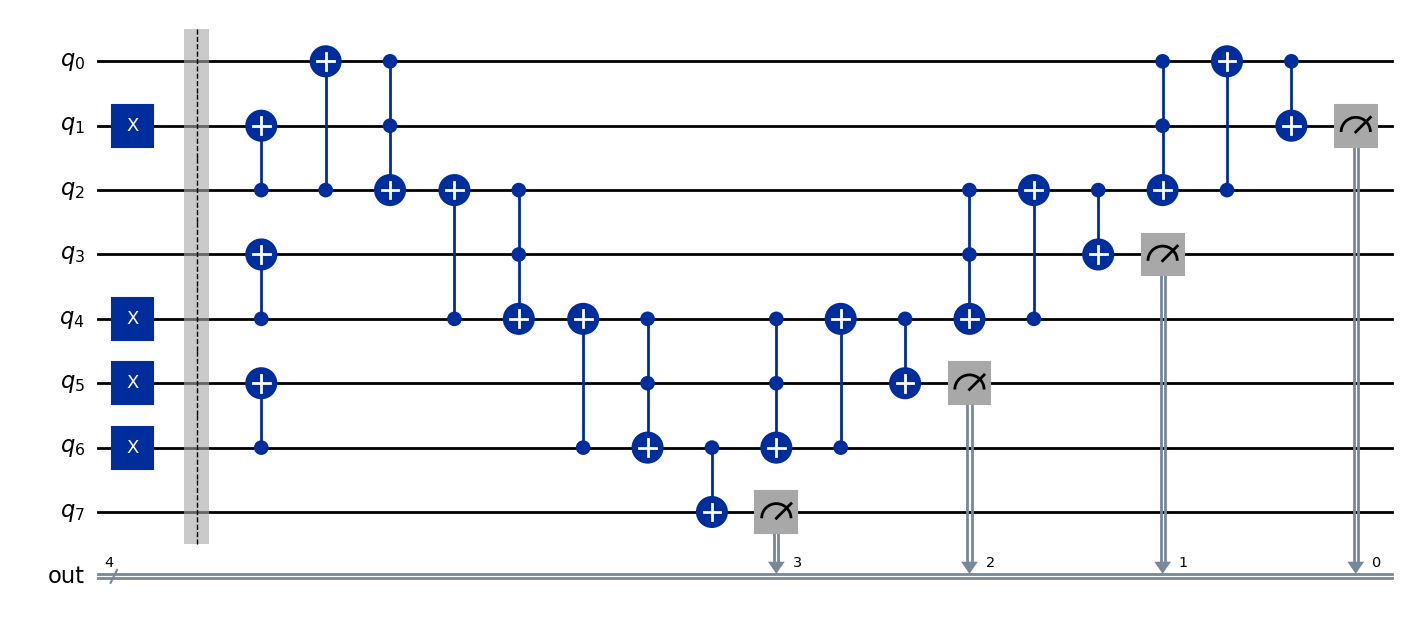

In [8]:
input_digits = 3

circuit_width = 2 * input_digits + 2
qreg = QuantumRegister(circuit_width, name='q')

creg = ClassicalRegister(input_digits+1, name='out')
circuit = QuantumCircuit(qreg, creg)

#a=5, b=6
#a0(1), a2(5), b1(4), b2(6)
for iq in [1, 5, 4, 6]:
    circuit.x(iq)

circuit.barrier()

# U
for qlow in range(0, circuit_width-2, 2):
    circuit.cx(qlow+2, qlow+1)
    circuit.cx(qlow+2, qlow)
    circuit.ccx(qlow, qlow+1, qlow+2)

circuit.cx(circuit_width-2, circuit_width-1)
# V
for qlow in range(circuit_width-4, -1, -2):
    circuit.ccx(qlow, qlow+1, qlow+2)
    circuit.cx(qlow+2, qlow)
    circuit.cx(qlow, qlow+1)
    
circuit.measure(range(1, circuit_width, 2), creg)

circuit.draw('mpl')